<a href="https://colab.research.google.com/github/pink3y3/link_prediction-citation_network/blob/main/citation_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Run this first — takes 1-2 mins
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 817.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.3 MB/s eta 0:00:00


In [3]:
import torch
import torch_geometric
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

print("=== CORA DATASET ===")
print(f"Nodes:           {data.num_nodes}")
print(f"Edges:           {data.num_edges}")
print(f"Node features:   {data.num_node_features}")
print(f"Classes:         {dataset.num_classes}")
print(f"Is undirected:   {data.is_undirected()}")

Processing...


=== CORA DATASET ===
Nodes:           2708
Edges:           10556
Node features:   1433
Classes:         7
Is undirected:   True


Done!


In [11]:
# Understand what's inside
print("=== DATA OBJECT ===")
print(data)
print()

# Node features shape
print(f"Feature matrix shape: {data.x.shape}")
# → [2708, 1433]
# 2708 nodes, each with 1433 features

# Edge connections
print(f"Edge index shape:     {data.edge_index.shape}")
# → [2, 10556]
# 2 rows: source nodes and target nodes

# Node labels (paper topic)
print(f"Labels shape:         {data.y.shape}")
# → [2708]
# One class label per node

# Train/val/test masks
print(f"\nTraining nodes:   {data.train_mask.sum().item()}")
print(f"Validation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes:       {data.test_mask.sum().item()}")

=== DATA OBJECT ===
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

Feature matrix shape: torch.Size([2708, 1433])
Edge index shape:     torch.Size([2, 10556])
Labels shape:         torch.Size([2708])

Training nodes:   140
Validation nodes: 500
Test nodes:       1000


In [6]:
# First 5 edges
print("=== FIRST 5 EDGES ===")
print("Source nodes:", data.edge_index[0][:5].tolist())
print("Target nodes:", data.edge_index[1][:5].tolist())

# First node's features (1433 values)
print("\n=== NODE 0 FEATURES ===")
print(f"Feature vector length: {len(data.x[0])}")
print(f"Non-zero features:     {(data.x[0] != 0).sum().item()}")
print(f"First 10 values:       {data.x[0][:10].tolist()}")

# Class labels
print("\n=== CLASS DISTRIBUTION ===")
for i in range(dataset.num_classes):
    count = (data.y == i).sum().item()
    print(f"Class {i}: {count} papers")

=== FIRST 5 EDGES ===
Source nodes: [633, 1862, 2582, 2, 652]
Target nodes: [0, 0, 0, 1, 1]

=== NODE 0 FEATURES ===
Feature vector length: 1433
Non-zero features:     9
First 10 values:       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

=== CLASS DISTRIBUTION ===
Class 0: 351 papers
Class 1: 217 papers
Class 2: 418 papers
Class 3: 818 papers
Class 4: 426 papers
Class 5: 298 papers
Class 6: 180 papers


=== DEGREE STATISTICS ===
Average degree:  3.90
Max degree:      168
Min degree:      1
Median degree:   3.00


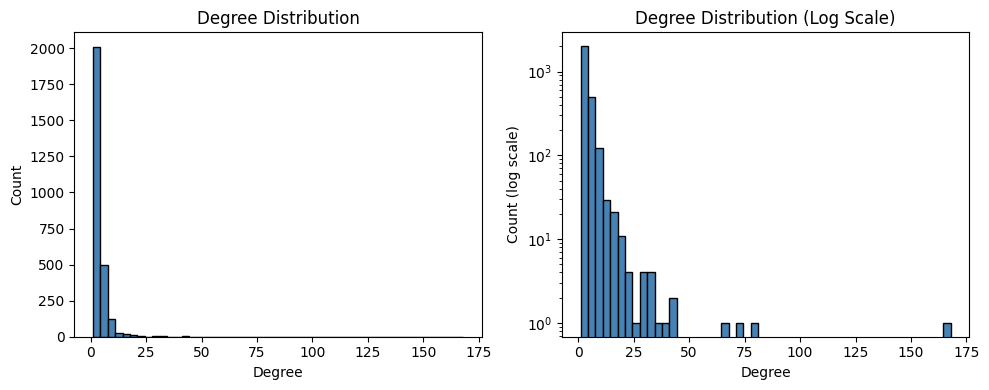

In [12]:
# Convert to NetworkX for analysis
G = to_networkx(data, to_undirected=True)

# Calculate degrees
degrees = [d for n, d in G.degree()]

print("=== DEGREE STATISTICS ===")
print(f"Average degree:  {np.mean(degrees):.2f}")
print(f"Max degree:      {np.max(degrees)}")
print(f"Min degree:      {np.min(degrees)}")
print(f"Median degree:   {np.median(degrees):.2f}")

# Plot degree distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(degrees, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.title('Degree Distribution')

plt.subplot(1, 2, 2)
plt.hist(degrees, bins=50, color='steelblue',
         edgecolor='black', log=True)
plt.xlabel('Degree')
plt.ylabel('Count (log scale)')
plt.title('Degree Distribution (Log Scale)')

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150)
plt.show()

In [9]:
print("=== GRAPH STATISTICS ===")

# Density
density = nx.density(G)
print(f"Graph density:          {density:.6f}")
print(f"→ Very sparse (close to 0 = sparse)")

# Average clustering coefficient
avg_clustering = nx.average_clustering(G)
print(f"\nAvg clustering coeff:   {avg_clustering:.4f}")
print(f"→ How cliquey the graph is (0-1)")

# Connected components
components = nx.number_connected_components(G)
print(f"\nConnected components:   {components}")

# Average shortest path (on largest component)
largest_cc = max(nx.connected_components(G), key=len)
subG = G.subgraph(largest_cc)
avg_path = nx.average_shortest_path_length(subG)
print(f"\nAvg shortest path:      {avg_path:.4f}")
print(f"→ Average hops between any two papers")

=== GRAPH STATISTICS ===
Graph density:          0.001440
→ Very sparse (close to 0 = sparse)

Avg clustering coeff:   0.2407
→ How cliquey the graph is (0-1)

Connected components:   78

Avg shortest path:      6.3110
→ Average hops between any two papers


In [10]:
print("=== IMPLICATIONS FOR LINK PREDICTION ===")
print()
print(f"1. Sparsity: {nx.density(G):.6f}")
print("   → Most node pairs have NO edge")
print("   → Negative sampling will be easy")
print()
print(f"2. Avg degree: {np.mean(degrees):.2f}")
print("   → Most papers cite ~4 others")
print("   → Some papers are highly cited (hubs)")
print()
print(f"3. Features: 1433 per node")
print("   → Word presence in paper title/abstract")
print("   → GNNs can USE this, heuristics CANNOT")
print()
print(f"4. 7 classes (paper topics)")
print("   → Papers in same class likely cite each other")
print("   → Good signal for link prediction")

=== IMPLICATIONS FOR LINK PREDICTION ===

1. Sparsity: 0.001440
   → Most node pairs have NO edge
   → Negative sampling will be easy

2. Avg degree: 3.90
   → Most papers cite ~4 others
   → Some papers are highly cited (hubs)

3. Features: 1433 per node
   → Word presence in paper title/abstract
   → GNNs can USE this, heuristics CANNOT

4. 7 classes (paper topics)
   → Papers in same class likely cite each other
   → Good signal for link prediction


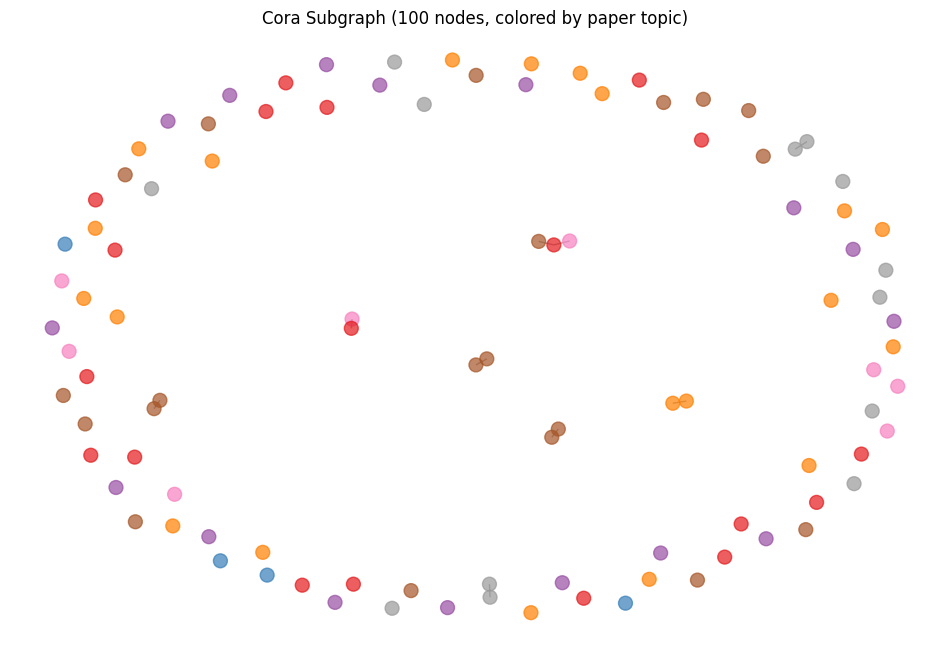

In [8]:
# Don't plot all 2708 nodes — too messy
# Plot a small subgraph of 100 nodes

subgraph_nodes = list(G.nodes())[:100]
subgraph = G.subgraph(subgraph_nodes)

# Color nodes by class
node_labels = data.y.numpy()
colors = [node_labels[n] for n in subgraph_nodes]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, seed=42)

nx.draw_networkx(
    subgraph,
    pos=pos,
    node_color=colors,
    cmap=plt.cm.Set1,
    node_size=100,
    with_labels=False,
    edge_color='gray',
    alpha=0.7
)

plt.title('Cora Subgraph (100 nodes, colored by paper topic)')
plt.axis('off')
plt.savefig('cora_subgraph.png', dpi=150)
plt.show()